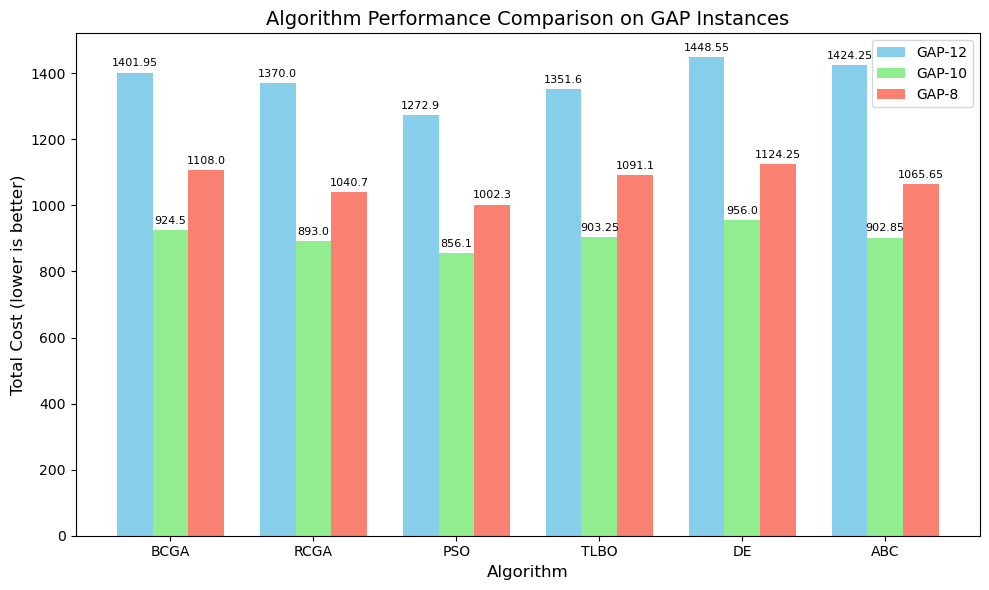

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create DataFrame from your results
data = {
    'Algorithm': ['BCGA', 'RCGA', 'PSO', 'TLBO', 'DE', 'ABC'],
    'GAP-12': [1401.95, 1370.00, 1272.90, 1351.60, 1448.55, 1424.25],
    'GAP-10': [924.50, 893.00, 856.10, 903.25, 956.00, 902.85],
    'GAP-8':  [1108.00, 1040.70,  1002.30,  1091.10,  1124.25,  1065.65]
}
df = pd.DataFrame(data)

# Set the position of bars on X axis
x = np.arange(len(df['Algorithm']))  # label locations
width = 0.25  # width of each bar

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each instance's bars
bars1 = ax.bar(x - width, df['GAP-12'], width, label='GAP-12', color='skyblue')
bars2 = ax.bar(x,         df['GAP-10'], width, label='GAP-10', color='lightgreen')
bars3 = ax.bar(x + width, df['GAP-8'],  width, label='GAP-8',  color='salmon')

# Add labels, title, and legend
ax.set_xlabel('Algorithm', fontsize=12)
ax.set_ylabel('Total Cost (lower is better)', fontsize=12)
ax.set_title('Algorithm Performance Comparison on GAP Instances', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df['Algorithm'])
ax.legend()

# Optional: add value labels on top of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

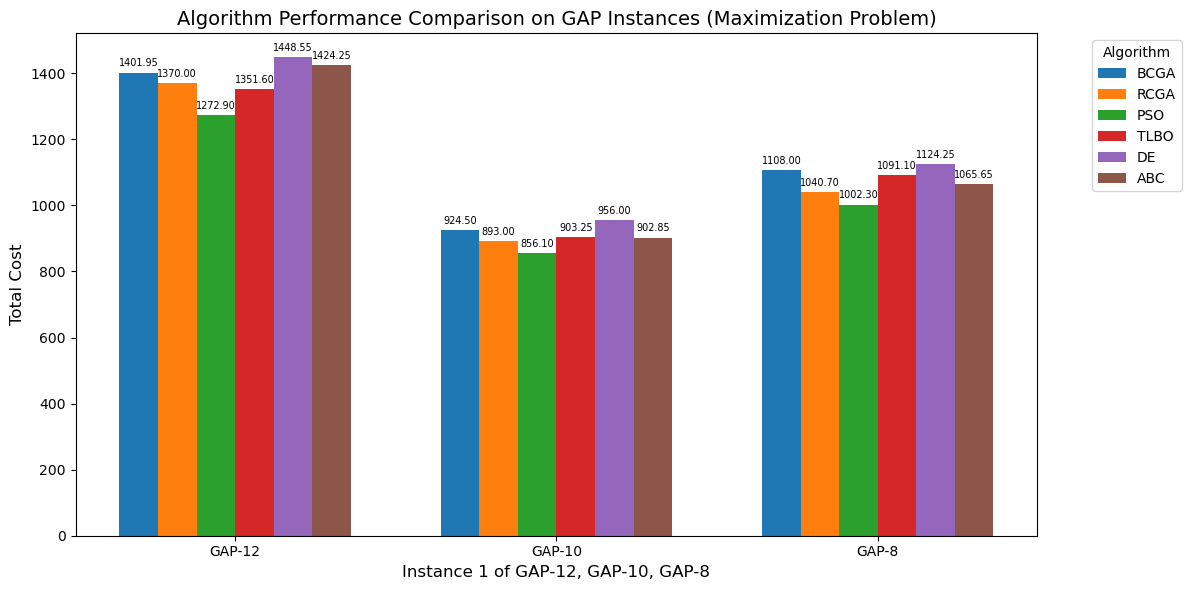

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Original data (algorithms as rows, instances as columns)
data = {
    'Algorithm': ['BCGA', 'RCGA', 'PSO', 'TLBO', 'DE', 'ABC'],
    'GAP-12': [1401.95, 1370.00, 1272.90, 1351.60, 1448.55, 1424.25],
    'GAP-10': [924.50, 893.00, 856.10, 903.25, 956.00, 902.85],
    'GAP-8':  [1108.00, 1040.70, 1002.30, 1091.10, 1124.25, 1065.65]
}
df = pd.DataFrame(data)

# Transpose: instances become rows, algorithms become columns
df_inst = df.set_index('Algorithm').T   # rows: GAP-12, GAP-10, GAP-8; cols: BCGA, RCGA, ...

# Set up plot
instances = df_inst.index.tolist()          # ['GAP-12', 'GAP-10', 'GAP-8']
algorithms = df_inst.columns.tolist()       # ['BCGA', 'RCGA', 'PSO', 'TLBO', 'DE', 'ABC']
n_algorithms = len(algorithms)
x = np.arange(len(instances))               # positions for instances
width = 0.12                                # bar width (adjust as needed)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot one bar per algorithm for each instance
for i, algo in enumerate(algorithms):
    offset = (i - n_algorithms/2 + 0.5) * width   # center the group of bars
    bars = ax.bar(x + offset, df_inst[algo], width, label=algo)

    # Optional: add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

# Customise axes
ax.set_xlabel('Instance 1 of GAP-12, GAP-10, GAP-8', fontsize=12)
ax.set_ylabel('Total Cost', fontsize=12)
ax.set_title('Algorithm Performance Comparison on GAP Instances (Maximization Problem)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(instances)
ax.legend(title='Algorithm', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()